In [57]:
# Rulează o singură dată la început
!pip install pandas numpy matplotlib scipy scikit-learn seaborn -q

In [58]:
!git clone https://github.com/joanna-/3D-Printing-Data.git
!ls 3D-Printing-Data/

Cloning into '3D-Printing-Data'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 122 (delta 2), reused 2 (delta 0), pack-reused 116 (from 1)
Receiving objects: 100% (122/122), 239.37 MiB | 27.58 MiB/s, done.
Resolving deltas: 100% (31/31), done.
Updating files: 100% (21/21), done.
docs  four_towers  four_towers_no_base	LICENSE  notebooks  README.md


In [59]:
# Descarcă întregul dataset dintr-o lovitură
!wget "https://github.com/joanna-/3D-Printing-Data/archive/refs/heads/master.zip" -O data.zip
!unzip -q data.zip
!ls 3D-Printing-Data-master/four_towers/

--2026-05-10 20:36:36--  https://github.com/joanna-/3D-Printing-Data/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/joanna-/3D-Printing-Data/zip/refs/heads/master [following]
--2026-05-10 20:36:36--  https://codeload.github.com/joanna-/3D-Printing-Data/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.114.10
Connecting to codeload.github.com (codeload.github.com)|140.82.114.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘data.zip’

data.zip                [  <=>               ] 182.72M  26.3MB/s    in 8.9s    

2026-05-10 20:36:45 (20.5 MB/s) - ‘data.zip’ saved [191600702]

arm_failure  bowden  plastic  proper  retraction  towers_v01.stl  unstick


In [60]:
ls

3D-Printing-Data/         data.zip  models/     README.md
3D-Printing-Data-master/  grafice/  notebooks/


In [61]:
# Extrage toate zip-urile din fiecare folder
!find 3D-Printing-Data-master/four_towers -name "*.zip" -exec unzip -q {} -d {}_extracted \;
!ls 3D-Printing-Data-master/four_towers/arm_failure/

arm_failure.zip  arm_failure.zip_extracted


In [62]:
!find 3D-Printing-Data-master/four_towers -name "*.txt" | head -20

3D-Printing-Data-master/four_towers/retraction/retraction_05.zip_extracted/retraction_05.txt
3D-Printing-Data-master/four_towers/arm_failure/arm_failure.zip_extracted/head_arm_failure.txt
3D-Printing-Data-master/four_towers/proper/proper.zip_extracted/proper/accel.txt
3D-Printing-Data-master/four_towers/plastic/plastic.zip_extracted/plastic/accel_plastic.txt
3D-Printing-Data-master/four_towers/bowden/bowden.zip_extracted/bowden/bowden_accel.txt
3D-Printing-Data-master/four_towers/unstick/unstick.zip_extracted/unstick/accel_unstick.txt


In [63]:
import pandas as pd
import glob, os

cols = ['index','timestamp_ms',
        'acc1_x','acc1_y','acc1_z',
        'acc2_x','acc2_y','acc2_z',
        'unknown','timestamp_unix']

# Căile exacte pentru fiecare fișier
fisiere = {
    'arm_failure': '3D-Printing-Data-master/four_towers/arm_failure/arm_failure.zip_extracted/head_arm_failure.txt',
    'retraction':  '3D-Printing-Data-master/four_towers/retraction/retraction_05.zip_extracted/retraction_05.txt',
    'proper':      '3D-Printing-Data-master/four_towers/proper/proper.zip_extracted/proper/accel.txt',
    'plastic':     '3D-Printing-Data-master/four_towers/plastic/plastic.zip_extracted/plastic/accel_plastic.txt',
    'bowden':      '3D-Printing-Data-master/four_towers/bowden/bowden.zip_extracted/bowden/bowden_accel.txt',
    'unstick':     '3D-Printing-Data-master/four_towers/unstick/unstick.zip_extracted/unstick/accel_unstick.txt',
}

dfs = []
for label, path in fisiere.items():
    df = pd.read_csv(path, header=None, names=cols)
    df['label'] = label
    dfs.append(df)
    print(f"✅ {label}: {len(df):,} rânduri")

df_all = pd.concat(dfs, ignore_index=True)
print(f"\nTOTAL: {len(df_all):,} rânduri")
print(df_all['label'].value_counts())


✅ arm_failure: 826,126 rânduri


/tmp/ipykernel_3303/1699722043.py:21: DtypeWarning: Columns (1,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, header=None, names=cols)


✅ retraction: 1,672,290 rânduri
✅ proper: 1,509,510 rânduri
✅ plastic: 302,739 rânduri
✅ bowden: 354,827 rânduri
✅ unstick: 1,673,747 rânduri

TOTAL: 6,339,239 rânduri
label
unstick        1673747
retraction     1672290
proper         1509510
arm_failure     826126
bowden          354827
plastic         302739
Name: count, dtype: int64


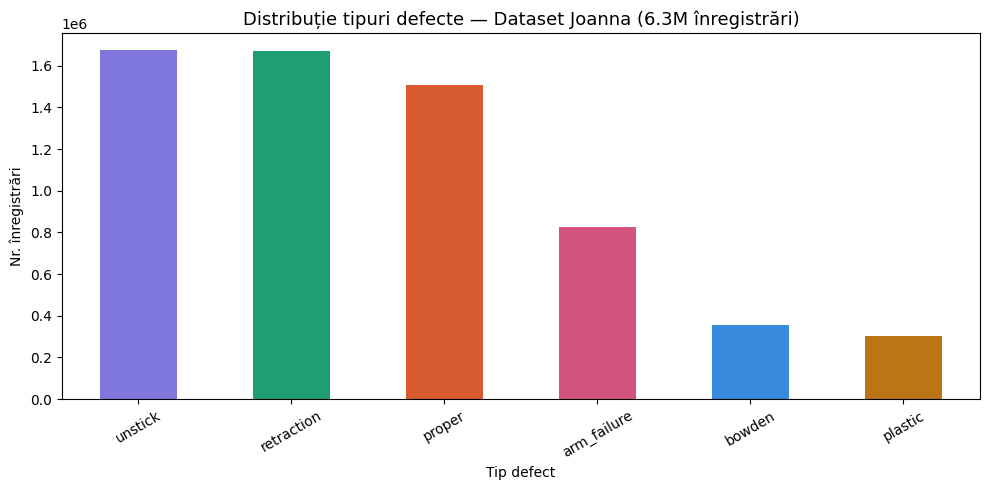

✅ Salvat: distributie_clase.png


In [64]:
import matplotlib.pyplot as plt

# Fix warning pentru viitor
df_all = pd.concat(dfs, ignore_index=True)

# Grafic distribuție clase - primul grafic din lucrare!
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#7F77DD','#1D9E75','#D85A30','#D4537E','#378ADD','#BA7517']
df_all['label'].value_counts().plot(kind='bar', ax=ax, color=colors)
ax.set_title('Distribuție tipuri defecte — Dataset Joanna (6.3M înregistrări)', fontsize=13)
ax.set_xlabel('Tip defect')
ax.set_ylabel('Nr. înregistrări')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('distributie_clase.png', dpi=150)
plt.show()
print("✅ Salvat: distributie_clase.png")

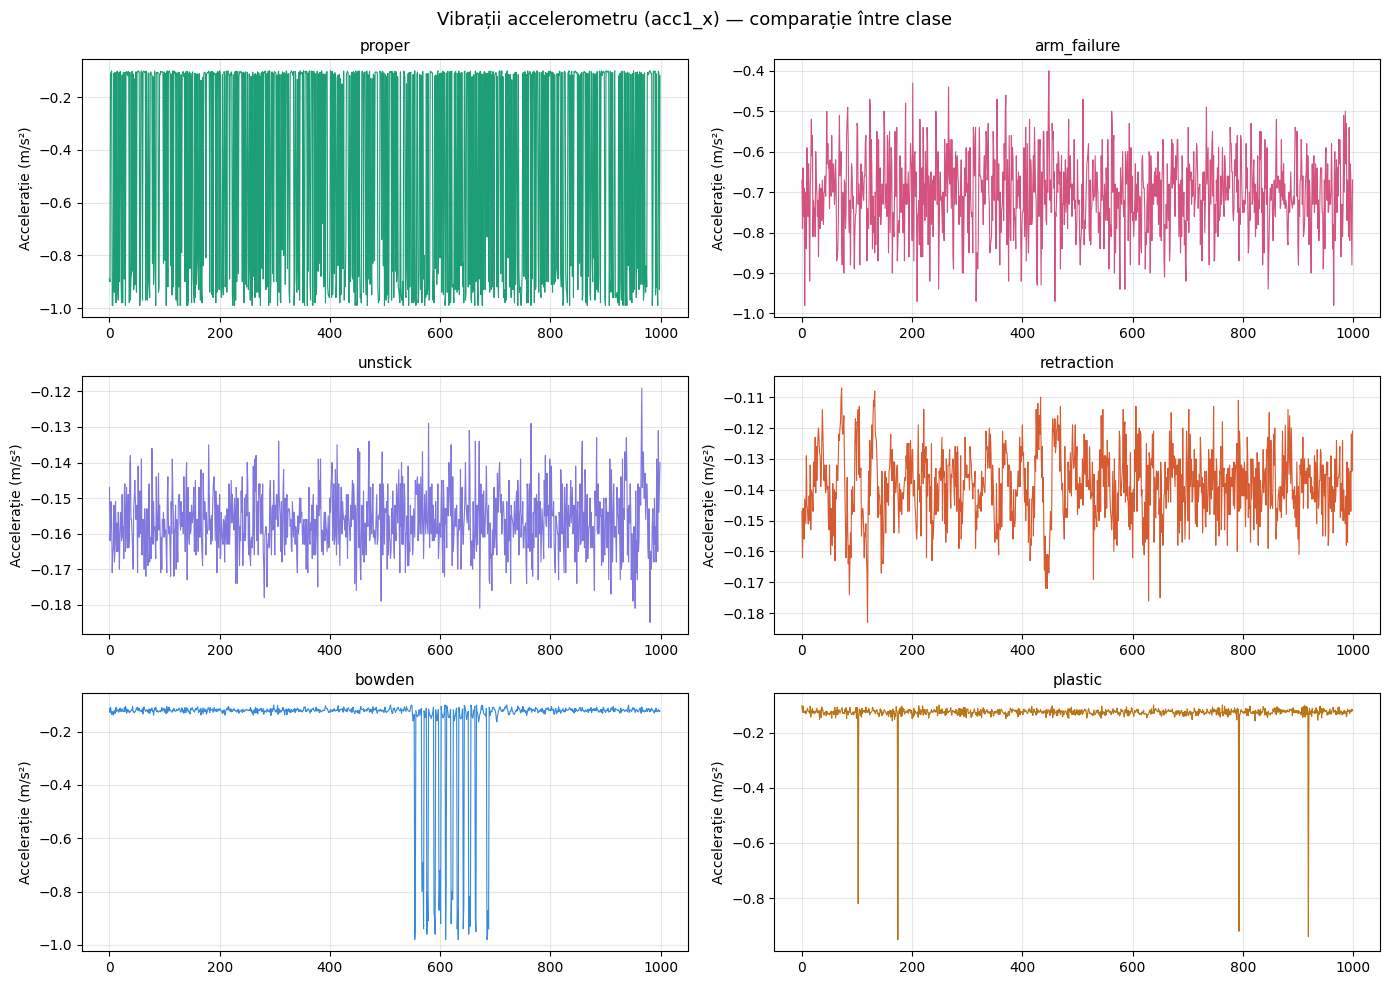

✅ Salvat: vibratii_comparatie.png


In [65]:
# Grafic vibrații brute pentru fiecare clasă
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Vibrații accelerometru (acc1_x) — comparație între clase', fontsize=13)

for ax, (label, color) in zip(axes.flatten(), [
    ('proper',      '#1D9E75'),
    ('arm_failure', '#D4537E'),
    ('unstick',     '#7F77DD'),
    ('retraction',  '#D85A30'),
    ('bowden',      '#378ADD'),
    ('plastic',     '#BA7517'),
]):
    data = df_all[df_all['label'] == label]['acc1_x'].values[:1000]
    ax.plot(data, color=color, linewidth=0.8)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Accelerație (m/s²)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vibratii_comparatie.png', dpi=150)
plt.show()
print("✅ Salvat: vibratii_comparatie.png")

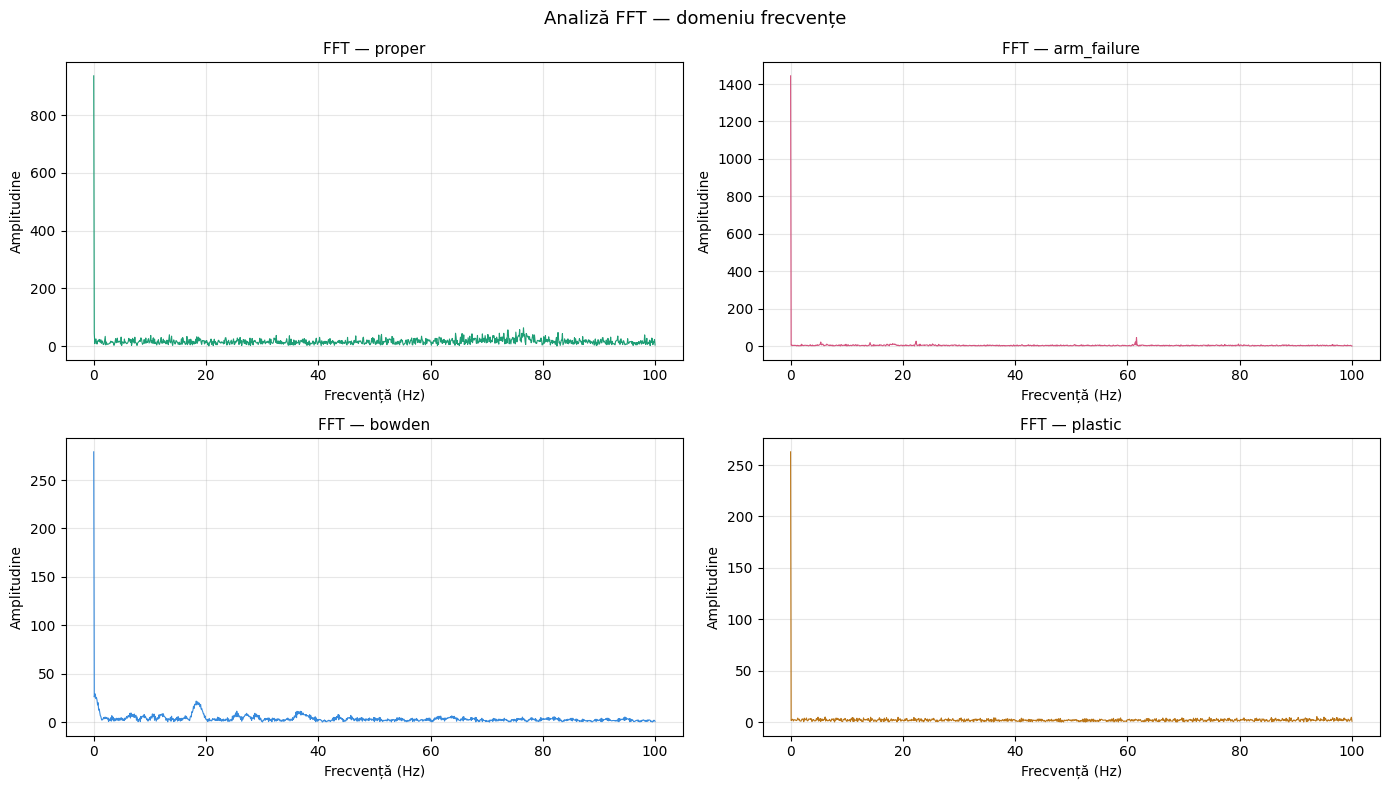

✅ Săptămâna 1 COMPLETĂ! Ai 3 grafice salvate.


In [66]:
import numpy as np
import matplotlib.pyplot as plt

# FFT comparativ între proper și arm_failure
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Analiză FFT — domeniu frecvențe', fontsize=13)

fs = 200  # Hz, frecvența de eșantionare MPU6050

for ax, (label, color) in zip(axes.flatten(), [
    ('proper',      '#1D9E75'),
    ('arm_failure', '#D4537E'),
    ('bowden',      '#378ADD'),
    ('plastic',     '#BA7517'),
]):
    data = df_all[df_all['label'] == label]['acc1_x'].dropna().values[:2048]
    fft_vals = np.abs(np.fft.rfft(data))
    fft_freq = np.fft.rfftfreq(len(data), d=1/fs)
    ax.plot(fft_freq, fft_vals, color=color, linewidth=0.8)
    ax.set_title(f'FFT — {label}', fontsize=11)
    ax.set_xlabel('Frecvență (Hz)')
    ax.set_ylabel('Amplitudine')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fft_comparatie.png', dpi=150)
plt.show()
print("✅ Săptămâna 1 COMPLETĂ! Ai 3 grafice salvate.")

In [67]:
import os

print("Contents of /content directory:")
for item in os.listdir('/content'):
    print(item)


Contents of /content directory:
.config
repo_curat
licenta-predictive-maintenance
sample_data


In [68]:
import os

print("Contents of /content directory:")
for item in os.listdir('/content'):
    print(item)


Contents of /content directory:
.config
repo_curat
licenta-predictive-maintenance
sample_data


In [69]:
import shutil, os

# Vezi exact ce notebooks există
notebooks = [f for f in os.listdir('/content') if f.endswith('.ipynb')]
print("Notebooks:", notebooks)

Notebooks: []


In [73]:
print(len(df_all))

6339239


✅ Train: 9904 exemple
✅ Test: 2476 exemple
✅ Clase: ['arm_failure' 'bowden' 'plastic' 'proper' 'retraction' 'unstick']

Antrenez Random Forest...
✅ Random Forest Accuracy: 0.6216 (62.16%)

Raport detaliat:
              precision    recall  f1-score   support

 arm_failure       0.49      0.34      0.40       323
      bowden       0.38      0.26      0.31       139
     plastic       0.46      0.36      0.41       118
      proper       0.59      0.76      0.67       589
  retraction       0.75      0.67      0.70       653
     unstick       0.64      0.71      0.68       654

    accuracy                           0.62      2476
   macro avg       0.55      0.52      0.53      2476
weighted avg       0.62      0.62      0.61      2476



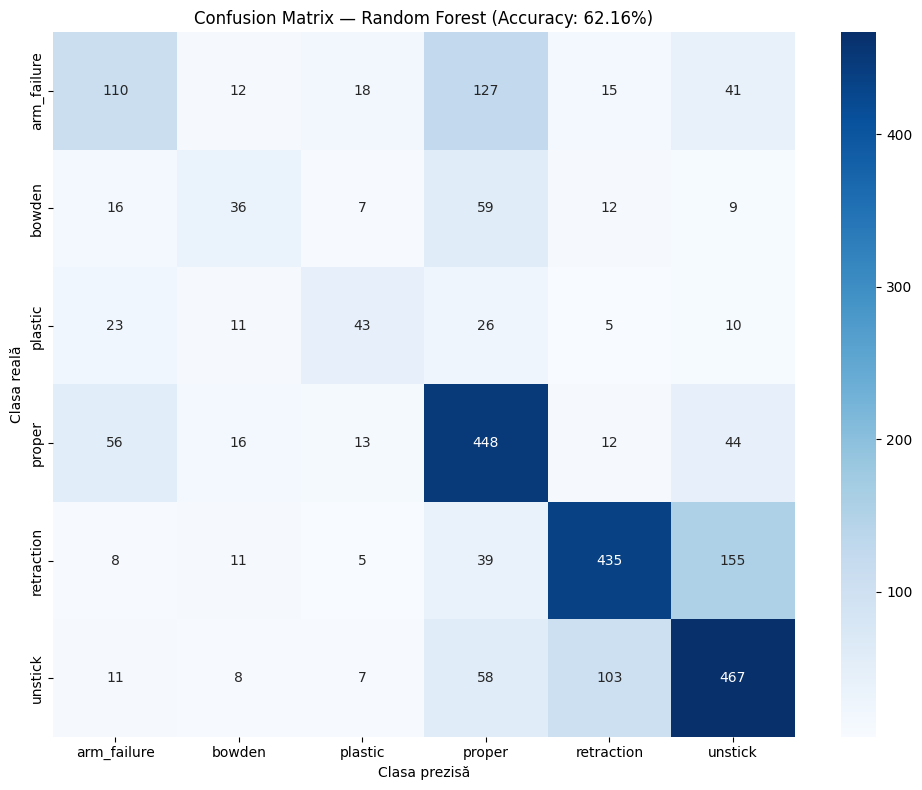

✅ Salvat: confusion_matrix_rf.png


In [75]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# ── Pasul 2: Pregătire date ──
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Train: {len(X_train)} exemple")
print(f"✅ Test: {len(X_test)} exemple")
print(f"✅ Clase: {le.classes_}")

# ── Pasul 3: Random Forest ──
print("\nAntrenez Random Forest...")
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"✅ Random Forest Accuracy: {acc_rf:.4f} ({acc_rf*100:.2f}%)")
print("\nRaport detaliat:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# ── Confusion Matrix RF ──
fig, ax = plt.subplots(figsize=(10, 8))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'Confusion Matrix — Random Forest (Accuracy: {acc_rf*100:.2f}%)')
ax.set_ylabel('Clasa reală')
ax.set_xlabel('Clasa prezisă')
plt.tight_layout()
plt.savefig('grafice/confusion_matrix_rf.png', dpi=150)
plt.show()
print("✅ Salvat: confusion_matrix_rf.png")

In [76]:
def extract_features_full(df, window_size=512):
    features = []
    labels = []

    axes = ['acc1_x', 'acc1_y', 'acc1_z', 'acc2_x', 'acc2_y', 'acc2_z']

    for label in df['label'].unique():
        subset = df[df['label'] == label][axes].copy()

        # Convertește la numeric și elimină valorile invalide
        for ax in axes:
            subset[ax] = pd.to_numeric(subset[ax], errors='coerce')
        subset = subset.dropna().values.astype(np.float64)

        for i in range(0, len(subset) - window_size, window_size):
            window = subset[i:i+window_size]

            feat = []
            for ax_idx in range(6):
                ax_data = window[:, ax_idx]
                fft_vals = np.abs(np.fft.rfft(ax_data))

                feat += [
                    np.mean(ax_data),
                    np.std(ax_data),
                    np.max(np.abs(ax_data)),
                    np.min(ax_data),
                    np.mean(fft_vals),
                    np.max(fft_vals),
                    float(np.argmax(fft_vals)),
                    np.sum(fft_vals**2),
                    np.sum(fft_vals[:10]),
                    np.sum(fft_vals[10:50]),
                    np.sum(fft_vals[50:]),
                ]

            features.append(feat)
            labels.append(label)

    return np.array(features), np.array(labels)

print("Extrag features din toate cele 6 axe...")
print("(Durează 3-5 minute...)")
X2, y2 = extract_features_full(df_all, window_size=512)
print(f"✅ Features extrase: {X2.shape}")
print(f"✅ Etichete: {len(y2)}")

Extrag features din toate cele 6 axe...
(Durează 3-5 minute...)
✅ Features extrase: (12380, 66)
✅ Etichete: 12380


✅ Train: 9904 exemple
✅ Test: 2476 exemple

Antrenez Random Forest (toate axele)...
✅ Random Forest Accuracy: 0.9774 (97.74%)

Raport detaliat:
              precision    recall  f1-score   support

 arm_failure       1.00      1.00      1.00       323
      bowden       0.96      0.94      0.95       139
     plastic       0.94      0.89      0.91       118
      proper       0.98      0.99      0.99       589
  retraction       0.97      0.99      0.98       653
     unstick       0.98      0.97      0.98       654

    accuracy                           0.98      2476
   macro avg       0.97      0.96      0.97      2476
weighted avg       0.98      0.98      0.98      2476



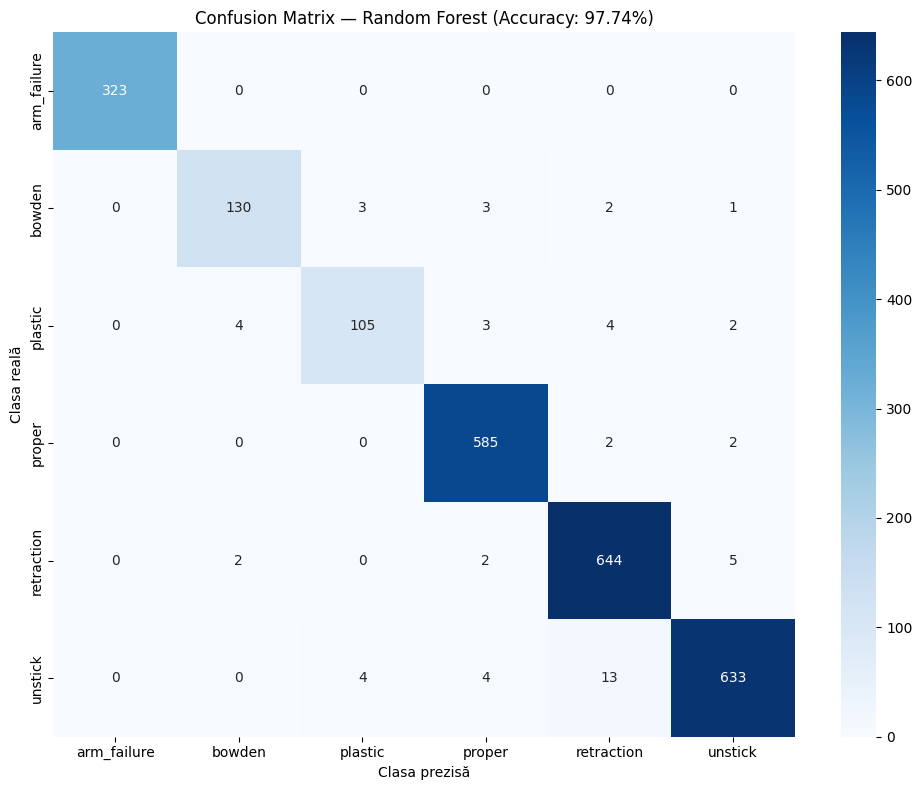

✅ Salvat: confusion_matrix_rf.png


In [77]:
# ── Pregătire date ──
le2 = LabelEncoder()
y2_encoded = le2.fit_transform(y2)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2_encoded, test_size=0.2, random_state=42, stratify=y2_encoded
)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

print(f"✅ Train: {len(X2_train)} exemple")
print(f"✅ Test: {len(X2_test)} exemple")

# ── Random Forest cu toate features ──
print("\nAntrenez Random Forest (toate axele)...")
rf2 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf2.fit(X2_train_scaled, y2_train)

y2_pred_rf = rf2.predict(X2_test_scaled)
acc_rf2 = accuracy_score(y2_test, y2_pred_rf)
print(f"✅ Random Forest Accuracy: {acc_rf2:.4f} ({acc_rf2*100:.2f}%)")
print("\nRaport detaliat:")
print(classification_report(y2_test, y2_pred_rf, target_names=le2.classes_))

# ── Confusion Matrix ──
fig, ax = plt.subplots(figsize=(10, 8))
cm_rf2 = confusion_matrix(y2_test, y2_pred_rf)
sns.heatmap(cm_rf2, annot=True, fmt='d', cmap='Blues',
            xticklabels=le2.classes_, yticklabels=le2.classes_, ax=ax)
ax.set_title(f'Confusion Matrix — Random Forest (Accuracy: {acc_rf2*100:.2f}%)')
ax.set_ylabel('Clasa reală')
ax.set_xlabel('Clasa prezisă')
plt.tight_layout()
plt.savefig('grafice/confusion_matrix_rf.png', dpi=150)
plt.show()
print("✅ Salvat: confusion_matrix_rf.png")


Antrenez SVM (poate dura 5-10 minute)...
✅ SVM Accuracy: 0.9059 (90.59%)

Raport detaliat:
              precision    recall  f1-score   support

 arm_failure       0.99      1.00      1.00       323
      bowden       0.93      0.81      0.87       139
     plastic       0.75      0.61      0.67       118
      proper       0.94      0.98      0.96       589
  retraction       0.90      0.87      0.88       653
     unstick       0.87      0.91      0.88       654

    accuracy                           0.91      2476
   macro avg       0.89      0.86      0.88      2476
weighted avg       0.90      0.91      0.90      2476



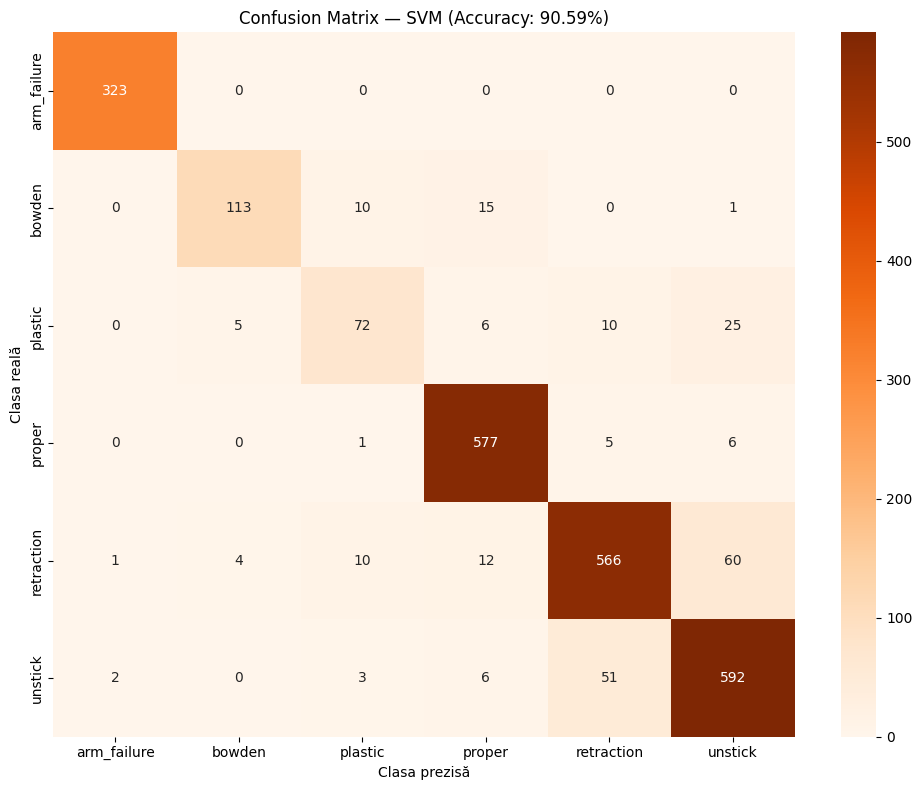

✅ Salvat: confusion_matrix_svm.png


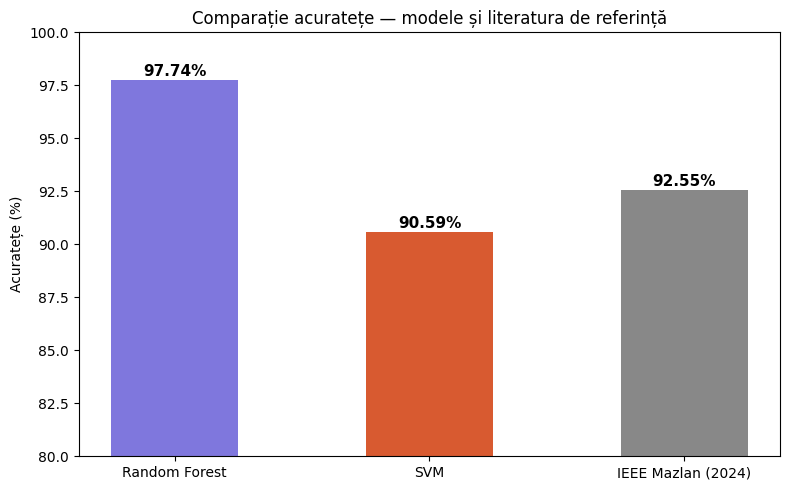

✅ Salvat: comparatie_modele.png


In [78]:
from sklearn.svm import SVC

print("Antrenez SVM (poate dura 5-10 minute)...")
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X2_train_scaled, y2_train)

y2_pred_svm = svm.predict(X2_test_scaled)
acc_svm = accuracy_score(y2_test, y2_pred_svm)
print(f"✅ SVM Accuracy: {acc_svm:.4f} ({acc_svm*100:.2f}%)")
print("\nRaport detaliat:")
print(classification_report(y2_test, y2_pred_svm, target_names=le2.classes_))

# ── Confusion Matrix SVM ──
fig, ax = plt.subplots(figsize=(10, 8))
cm_svm = confusion_matrix(y2_test, y2_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le2.classes_, yticklabels=le2.classes_, ax=ax)
ax.set_title(f'Confusion Matrix — SVM (Accuracy: {acc_svm*100:.2f}%)')
ax.set_ylabel('Clasa reală')
ax.set_xlabel('Clasa prezisă')
plt.tight_layout()
plt.savefig('grafice/confusion_matrix_svm.png', dpi=150)
plt.show()
print("✅ Salvat: confusion_matrix_svm.png")

# ── Grafic comparație ──
fig, ax = plt.subplots(figsize=(8, 5))
modele = ['Random Forest', 'SVM', 'IEEE Mazlan (2024)']
acurateti = [acc_rf2*100, acc_svm*100, 92.55]
culori = ['#7F77DD', '#D85A30', '#888888']
bars = ax.bar(modele, acurateti, color=culori, width=0.5)
ax.set_ylim(80, 100)
ax.set_ylabel('Acuratețe (%)')
ax.set_title('Comparație acuratețe — modele și literatura de referință')
for bar, val in zip(bars, acurateti):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('grafice/comparatie_modele.png', dpi=150)
plt.show()
print("✅ Salvat: comparatie_modele.png")

In [81]:
import matplotlib.pyplot as plt
import numpy as np

dst = '/content/repo_curat/grafice/'

# Grafic 1 - distributie
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#7F77DD','#1D9E75','#D85A30','#D4537E','#378ADD','#BA7517']
df_all['label'].value_counts().plot(kind='bar', ax=ax, color=colors)
ax.set_title('Distribuție tipuri defecte — Dataset Joanna (6.3M înregistrări)', fontsize=13)
ax.set_xlabel('Tip defect')
ax.set_ylabel('Nr. înregistrări')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(dst + 'distributie_clase.png', dpi=150)
plt.close()
print("✅ distributie_clase.png")

# Grafic 2 - vibratii
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Vibrații accelerometru (acc1_x) — comparație între clase', fontsize=13)
for ax, (label, color) in zip(axes.flatten(), [
    ('proper','#1D9E75'), ('arm_failure','#D4537E'),
    ('unstick','#7F77DD'), ('retraction','#D85A30'),
    ('bowden','#378ADD'), ('plastic','#BA7517'),
]):
    data = df_all[df_all['label'] == label]['acc1_x'].values[:1000]
    ax.plot(data, color=color, linewidth=0.8)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Accelerație (m/s²)')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(dst + 'vibratii_comparatie.png', dpi=150)
plt.close()
print("✅ vibratii_comparatie.png")

# Grafic 3 - FFT
fs = 200
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Analiză FFT — domeniu frecvențe', fontsize=13)
for ax, (label, color) in zip(axes.flatten(), [
    ('proper','#1D9E75'), ('arm_failure','#D4537E'),
    ('bowden','#378ADD'), ('plastic','#BA7517'),
]):
    data = df_all[df_all['label'] == label]['acc1_x'].dropna().values[:2048]
    fft_vals = np.abs(np.fft.rfft(data))
    fft_freq = np.fft.rfftfreq(len(data), d=1/fs)
    ax.plot(fft_freq, fft_vals, color=color, linewidth=0.8)
    ax.set_title(f'FFT — {label}', fontsize=11)
    ax.set_xlabel('Frecvență (Hz)')
    ax.set_ylabel('Amplitudine')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(dst + 'fft_comparatie.png', dpi=150)
plt.close()
print("✅ fft_comparatie.png")

print("\nToate graficele:")
print(os.listdir(dst))

✅ distributie_clase.png
✅ vibratii_comparatie.png
✅ fft_comparatie.png

Toate graficele:
['comparatie_modele.png', 'confusion_matrix_rf.png', 'confusion_matrix_svm.png', 'vibratii_comparatie.png', 'distributie_clase.png', 'fft_comparatie.png']
